# IronHorse YOLO Train

##Purpose
This notebook trains and evaluates a YOLO model on the IronHorse dataset

This notebook assumes the data set is already in the YOLO format

##What this notebook does

This notebook performs the following steps:

1. **Mounts Google Drive**  
   Connects Colab to Google Drive so the dataset ZIP file can be accessed.

2. **Extracts the dataset ZIP file**  
   Unzips the dataset into the Colab runtime.

3. **Creates a train/validation split**  
   Splits the dataset into:
   - 80% training images
   - 20% validation images

4. **Creates a YOLO dataset configuration file**  
   Writes a `.yaml` file that tells YOLO where the training and validation images are located.

5. **Trains a YOLOv8 model**  
   Fine-tunes a YOLOv8 small model using the prepared dataset.

6. **Validates the trained model**  
   Loads the best trained model weights and prints evaluation metrics such as precision, recall, mAP50, and mAP50-95.

7. **Plots training metrics**  
   Displays validation metrics over the training epochs.

8. **Displays the confusion matrix**  
   Opens and shows the confusion matrix image generated during training.

9. **Compares ground truth with predictions**  
   Draws ground-truth boxes and predicted boxes on images so the model’s performance can be reviewed visually.

10. **Zips review images**  
   Creates a ZIP file of the visual review images so they can be downloaded from Colab.

## Dataset format expected

This notebook expects the extracted dataset to contain a YOLO-style folder structure similar to:

```text
dataset_raw/
└── train/
    ├── images/
    │   ├── image_1.jpg
    │   ├── image_2.jpg
    │   └── ...
    └── labels/
        ├── image_1.txt
        ├── image_2.txt
        └── ...
```
## How to use this notebook
1. Make sure the dataset file is stored in Google Drive
2. Update the data zip path if needed:
```python
zip_path = "/content/drive/MyDrive/updatedDataSet.zip"
```
3. Run the cells from top to bottom
4. Train the YOLO model using the training cell
5. Review the validation metrics after training
6. Review the plotted training curves and confusion matrix
7. Run the ground-truth-versus-prediction cell to get a folder of images with the models predictions layered over the ground_truths

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os
import shutil

zip_path = "/content/drive/MyDrive/updatedDataSet.zip" #change path if needed
extract_dir = "/content/dataset_raw"

# clean old folder if it exists
if os.path.exists(extract_dir):
    shutil.rmtree(extract_dir)

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_dir)

print("Extracted to:", extract_dir)
print("Top-level contents:", os.listdir(extract_dir))

Extracted to: /content/dataset_raw
Top-level contents: ['train', 'data.yaml', 'README.roboflow.txt']


In [ ]:
import os
import shutil
import random

random.seed(42)

dataset_root = "/content/dataset_raw/train"

src_train_images = os.path.join(dataset_root, "images")
src_train_labels = os.path.join(dataset_root, "labels")

out_root = "/content/dataset2_yolo_split"
if os.path.exists(out_root):
    shutil.rmtree(out_root)

for sub in ["train/images", "train/labels", "val/images", "val/labels"]:
    os.makedirs(os.path.join(out_root, sub), exist_ok=True)

image_exts = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
images = [f for f in os.listdir(src_train_images) if f.lower().endswith(image_exts)]
images.sort()
random.shuffle(images)

split_idx = int(0.80 * len(images))   # 80/20 split
train_imgs = images[:split_idx]
val_imgs = images[split_idx:]

def copy_split(file_list, split_name):
    copied_images = 0
    copied_labels = 0
    missing_labels = 0

    for img_name in file_list:
        img_src = os.path.join(src_train_images, img_name)
        img_dst = os.path.join(out_root, split_name, "images", img_name)
        shutil.copy2(img_src, img_dst)
        copied_images += 1

        label_name = os.path.splitext(img_name)[0] + ".txt"
        lbl_src = os.path.join(src_train_labels, label_name)
        lbl_dst = os.path.join(out_root, split_name, "labels", label_name)

        if os.path.exists(lbl_src):
            shutil.copy2(lbl_src, lbl_dst)
            copied_labels += 1
        else:
            open(lbl_dst, "w").close()
            missing_labels += 1

    return copied_images, copied_labels, missing_labels

train_stats = copy_split(train_imgs, "train")
val_stats = copy_split(val_imgs, "val")

print("Train stats (images, labels, missing_labels):", train_stats)
print("Val stats   (images, labels, missing_labels):", val_stats)
print("Split dataset saved to:", out_root)

Train stats (images, labels, missing_labels): (192, 192, 0)
Val stats   (images, labels, missing_labels): (49, 49, 0)
Split dataset saved to: /content/dataset2_yolo_split


In [ ]:
data_yaml = """
train: /content/dataset2_yolo_split/train/images
val: /content/dataset2_yolo_split/val/images

nc: 1
names: ["unhealthy_leaf"]
"""

with open("/content/dataset2_unhealthy.yaml", "w") as f:
    f.write(data_yaml)

print(open("/content/dataset2_unhealthy.yaml").read())


train: /content/dataset2_yolo_split/train/images
val: /content/dataset2_yolo_split/val/images

nc: 1
names: ["unhealthy_leaf"]



In [ ]:
!pip install ultralytics -q

from ultralytics import YOLO
from pathlib import Path

model = YOLO("yolov8s.pt")

model.train(
    data="/content/dataset2_unhealthy.yaml",
    epochs=100,
    patience=15,
    imgsz=1280,
    batch=8,
    cache=True,
    lr0=0.01,
    project="/content/runs",
    name="dataset2_finetune"
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 40.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset2_unhealthy.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, for

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fcca5e93e00>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
!pip install ultralytics -q

from ultralytics import YOLO
from pathlib import Path

model = YOLO("/content/runs/dataset2_finetune/weights/best.pt")
metrics = model.val(data="/content/dataset2_unhealthy.yaml")

print("Fold_2metrics")
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
Model summary (fused): 113 layers, 43,607,379 parameters, 0 gradients, 164.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4142.1±1050.9 MB/s, size: 1835.5 KB)
val: Scanning /content/dataset2_yolo_split/val/labels.cache... 49 images, 7 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 49/49 17.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.3it/s 3.0s
                   all         49        115      0.489      0.513      0.417      0.125
Speed: 12.9ms preprocess, 9.7ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to /content/runs/detect/val-2
Fold_2metrics
Precision: 0.48915754165629066
Recall: 0.5130434782608696
mAP50: 0.41740536316331334
mAP50-95: 0.1246619018766583


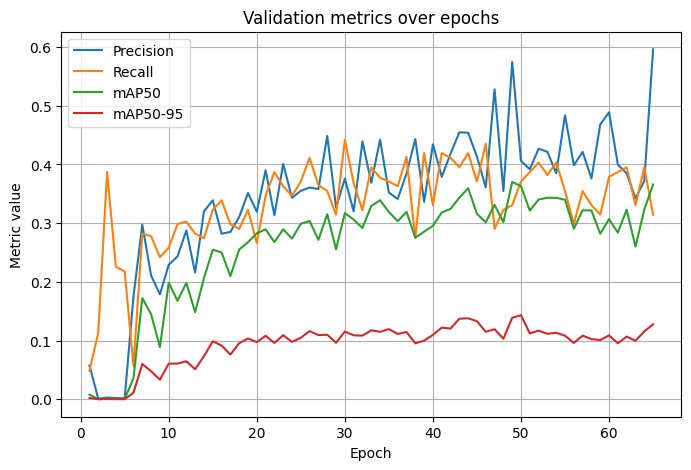

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/runs/dataset2_finetune/results.csv")
plt.figure(figsize=(8, 5))
plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
plt.xlabel("Epoch")
plt.ylabel("Metric value")
plt.title("Validation metrics over epochs")
plt.legend()
plt.grid(True)
plt.show()

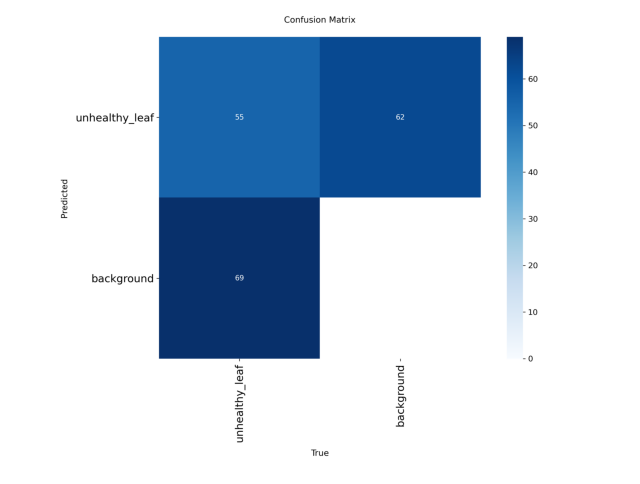

In [ ]:
from PIL import Image

img = Image.open("/content/runs/dataset2_finetune/confusion_matrix.png")
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
!pip install ultralytics -q
from ultralytics import YOLO
import cv2
from pathlib import Path

# ----------------------------
# PATHS
# ----------------------------
model_path = "/content/hyperlast.pt"   # change to model
dataset_root = Path("/content/dataset2_yolo_split")
output_root = Path("/content/gt_vs_pred2")

train_images_dir = dataset_root / "train" / "images"
train_labels_dir = dataset_root / "train" / "labels"
val_images_dir   = dataset_root / "val" / "images"
val_labels_dir   = dataset_root / "val" / "labels"

(output_root / "train").mkdir(parents=True, exist_ok=True)
(output_root / "val").mkdir(parents=True, exist_ok=True)

# ----------------------------
# COLORS / SETTINGS
# ----------------------------
GT_COLOR = (0, 0, 255)      # red
PRED_COLOR = (0, 255, 255)    # yellow
CONF_THRES = 0.30
IOU_THRES = 0.05

model = YOLO(model_path)

def yolo_to_xyxy(line, img_w, img_h):
    parts = line.strip().split()
    if len(parts) < 5:
        return None

    cls_id = int(float(parts[0]))
    x_c = float(parts[1]) * img_w
    y_c = float(parts[2]) * img_h
    w = float(parts[3]) * img_w
    h = float(parts[4]) * img_h

    x1 = int(x_c - w / 2)
    y1 = int(y_c - h / 2)
    x2 = int(x_c + w / 2)
    y2 = int(y_c + h / 2)

    return cls_id, x1, y1, x2, y2

def draw_ground_truth(img, label_path):
    h, w = img.shape[:2]

    if not label_path.exists():
        return img

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        parsed = yolo_to_xyxy(line, w, h)
        if parsed is None:
            continue

        _, x1, y1, x2, y2 = parsed

        cv2.rectangle(img, (x1, y1), (x2, y2), GT_COLOR, 2)
        cv2.putText(
            img,
            "GT",
            (x1, max(y1 - 8, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            GT_COLOR,
            2
        )

    return img

def draw_predictions(img, result):
    for box in result.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = float(box.conf[0])

        cv2.rectangle(img, (x1, y1), (x2, y2), PRED_COLOR, 2)
        cv2.putText(
            img,
            f"{conf:.2f}",
            (x1, min(y2 + 20, img.shape[0] - 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            PRED_COLOR,
            2
        )

    return img

def process_folder(images_dir, labels_dir, save_dir):
    image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
    image_files = sorted([p for p in images_dir.iterdir() if p.suffix.lower() in image_extensions])

    print(f"Processing {len(image_files)} images from {images_dir}")

    for img_path in image_files:
        label_path = labels_dir / f"{img_path.stem}.txt"

        img = cv2.imread(str(img_path))
        if img is None:
            print(f"Could not read: {img_path}")
            continue

        result = model.predict(
            source=str(img_path),
            conf=CONF_THRES,
            iou=IOU_THRES,
            save=False,
            verbose=False
        )[0]

        img = draw_ground_truth(img, label_path)
        img = draw_predictions(img, result)

        out_path = save_dir / img_path.name
        cv2.imwrite(str(out_path), img)

    print(f"Saved outputs to {save_dir}")

process_folder(train_images_dir, train_labels_dir, output_root / "train")
process_folder(val_images_dir, val_labels_dir, output_root / "val")

print(f"Done. Outputs saved under: {output_root}")

Processing 192 images from /content/dataset2_yolo_split/train/images
Saved outputs to /content/gt_vs_pred2/train
Processing 49 images from /content/dataset2_yolo_split/val/images
Saved outputs to /content/gt_vs_pred2/val
Done. Outputs saved under: /content/gt_vs_pred2


In [ ]:
import shutil

review_dir = "/content/gt_vs_pred"
zip_base = "/content/gt_vs_pred"

shutil.make_archive(zip_base, "zip", review_dir)
print("Created:", zip_base + ".zip")

Created: /content/gt_vs_pred.zip
